In [1]:

# Cell 1: Install libraries

!pip -q install ultralytics opencv-python-headless pandas openpyxl matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 3.1 MB/s eta 0:00:00


In [2]:

# Cell 2: Imports and configuration

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from google.colab import files
from pathlib import Path
from datetime import datetime
from IPython.display import display

# Project configuration
PROJECT_DIR = Path("/content/smart_bottle_project")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_VIDEO = PROJECT_DIR / "processed_bottle_video.mp4"
CSV_FILE = PROJECT_DIR / "bottle_video_history.csv"
EXCEL_FILE = PROJECT_DIR / "bottle_video_history.xlsx"

# Load pretrained YOLO model
model = YOLO("yolo11n.pt")

# COCO dataset bottle class
BOTTLE_CLASS_ID = 39

# Confidence threshold
CONFIDENCE_THRESHOLD = 0.35

print("Model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Model loaded successfully!


In [4]:

# Cell 3: Upload video

uploaded = files.upload()

if not uploaded:
    raise ValueError("No video uploaded.")

video_path = next(iter(uploaded))

print("Uploaded video:", video_path)

Saving bottle counting.mp4 to bottle counting.mp4
Uploaded video: bottle counting.mp4


In [5]:

# Cell 4: Bottle detection

def detect_bottles(frame, confidence=CONFIDENCE_THRESHOLD):

    results = model.predict(
        source=frame,
        conf=confidence,
        classes=[BOTTLE_CLASS_ID],
        verbose=False
    )

    result = results[0]
    annotated_frame = frame.copy()
    detections = []

    if result.boxes is None:
        return annotated_frame, 0, detections

    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()

    for box, score in zip(boxes, confidences):

        x1, y1, x2, y2 = map(int, box)

        detections.append({
            "class": "bottle",
            "confidence": float(score),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2
        })

        # Bounding box
        cv2.rectangle(
            annotated_frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Label
        label = f"Bottle {score:.2f}"

        cv2.putText(
            annotated_frame,
            label,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    bottle_count = len(detections)

    # Count overlay
    cv2.rectangle(
        annotated_frame,
        (10, 10),
        (330, 65),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        annotated_frame,
        f"Visible Bottles: {bottle_count}",
        (20, 47),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2
    )

    return annotated_frame, bottle_count, detections

In [6]:

# Cell 5: Process conveyor belt video

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("Could not open uploaded video.")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if fps <= 0:
    fps = 25.0

# MP4 video writer
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    str(OUTPUT_VIDEO),
    fourcc,
    fps,
    (width, height)
)

if not writer.isOpened():
    cap.release()
    raise ValueError("Could not create output video.")

history_records = []

frame_number = 0
processed_frames = 0
max_visible_bottles = 0

# Save one history record every N processed frames
HISTORY_INTERVAL = 5

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # Detect bottles in every frame
    annotated_frame, bottle_count, detections = detect_bottles(frame)

    processed_frames += 1

    max_visible_bottles = max(
        max_visible_bottles,
        bottle_count
    )

    # Save detection history at intervals
    if frame_number % HISTORY_INTERVAL == 0:

        confidence_values = [
            item["confidence"] for item in detections
        ]

        avg_confidence = (
            float(np.mean(confidence_values))
            if confidence_values else 0.0
        )

        history_records.append({
            "Frame": frame_number,
            "Time (seconds)": round(frame_number / fps, 2),
            "Visible Bottle Count": bottle_count,
            "Average Confidence": round(avg_confidence, 4)
        })

    # Write annotated frame to output video
    writer.write(annotated_frame)

    # Show periodic progress in notebook
    if frame_number % 30 == 0:

        progress = (
            (frame_number / total_frames) * 100
            if total_frames > 0 else 0
        )

        print(
            f"Frame: {frame_number}/{total_frames} | "
            f"Progress: {progress:.1f}% | "
            f"Visible bottles: {bottle_count}"
        )

cap.release()
writer.release()

history_df = pd.DataFrame(history_records)

print("\nVideo processing completed!")
print("Frames processed:", processed_frames)
print("Maximum visible bottles:", max_visible_bottles)
print("Output video:", OUTPUT_VIDEO)

Frame: 30/1294 | Progress: 2.3% | Visible bottles: 8
Frame: 60/1294 | Progress: 4.6% | Visible bottles: 7
Frame: 90/1294 | Progress: 7.0% | Visible bottles: 6
Frame: 120/1294 | Progress: 9.3% | Visible bottles: 8
Frame: 150/1294 | Progress: 11.6% | Visible bottles: 7
Frame: 180/1294 | Progress: 13.9% | Visible bottles: 10
Frame: 210/1294 | Progress: 16.2% | Visible bottles: 7
Frame: 240/1294 | Progress: 18.5% | Visible bottles: 8
Frame: 270/1294 | Progress: 20.9% | Visible bottles: 9
Frame: 300/1294 | Progress: 23.2% | Visible bottles: 12
Frame: 330/1294 | Progress: 25.5% | Visible bottles: 10
Frame: 360/1294 | Progress: 27.8% | Visible bottles: 12
Frame: 390/1294 | Progress: 30.1% | Visible bottles: 13
Frame: 420/1294 | Progress: 32.5% | Visible bottles: 10
Frame: 450/1294 | Progress: 34.8% | Visible bottles: 10
Frame: 480/1294 | Progress: 37.1% | Visible bottles: 10
Frame: 510/1294 | Progress: 39.4% | Visible bottles: 7
Frame: 540/1294 | Progress: 41.7% | Visible bottles: 8
Frame: 57

In [7]:

# Cell 6: Save history to CSV and Excel

if history_df.empty:
    print("No history records were generated.")
else:

    history_df.to_csv(
        CSV_FILE,
        index=False
    )

    history_df.to_excel(
        EXCEL_FILE,
        index=False,
        sheet_name="Bottle History"
    )

    print("CSV saved:", CSV_FILE)
    print("Excel saved:", EXCEL_FILE)

    display(history_df.head(10))

CSV saved: /content/smart_bottle_project/bottle_video_history.csv
Excel saved: /content/smart_bottle_project/bottle_video_history.xlsx


,Frame,Time (seconds),Visible Bottle Count,Average Confidence
0,5,0.08,14,0.5652
1,10,0.17,7,0.6337
2,15,0.25,7,0.6379
3,20,0.33,8,0.6142
4,25,0.42,8,0.6173
5,30,0.50,8,0.6007
6,35,0.58,9,0.5758
7,40,0.67,7,0.6398
8,45,0.75,7,0.6400
9,50,0.83,9,0.5825


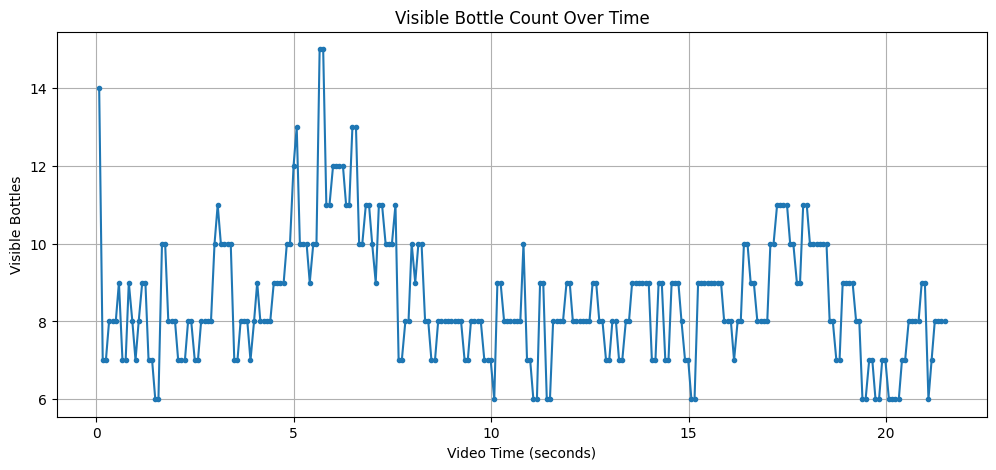

In [8]:

# Cell 7: Visualize bottle count over time

if not history_df.empty:

    plt.figure(figsize=(12, 5))

    plt.plot(
        history_df["Time (seconds)"],
        history_df["Visible Bottle Count"],
        marker="o",
        markersize=3
    )

    plt.title("Visible Bottle Count Over Time")
    plt.xlabel("Video Time (seconds)")
    plt.ylabel("Visible Bottles")
    plt.grid(True)
    plt.show()

else:
    print("No data available for chart.")

In [9]:

# Cell 9: Download project files

files.download(str(OUTPUT_VIDEO))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:

files.download(str(EXCEL_FILE))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>